# Escape from Competing L2 Responses — Summary

1. Analytical question

2. Response opportunity

3. From opportunity to modelling

4. Parsimonious account — E04: escape_L2 ~ Focus + Agent

5. Broader theoretical account — E07: escape_L2 ~ Focus + Agent + Goal_Type

6. E04 vs E07

7. Escape_L2 synthesis


Import libraries

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [64]:
import statsmodels.formula.api as smf
import statsmodels.api as sm
from scipy.stats import chi2

1. Analytical question:

   **What determines whether participants abandon competing L2 responses?**

2. Response opportunity

In [65]:
goal_summary_metrics = pd.read_csv("../../reports/tables/goal_summary_metrics.csv",
                                   index_col=[0, 1, 2])
goal_summary_metrics

L2_suppression  L1_shift  Correct_gain  \
Goal_Type         Agent Focus                                           
goal_frequent     0     I            0.152174  0.010870      0.141304   
                        They         0.166667  0.138889      0.027778   
                  1     I            0.375000  0.187500      0.187500   
                        They         0.500000  0.375000      0.125000   
goal_non_frequent 0     I            0.166667  0.041667      0.125000   
                        They         0.444444  0.527778     -0.083333   
                  1     I            0.437500  0.437500      0.000000   
                        They         0.500000  0.375000      0.125000   

                               Conversion_efficiency  
Goal_Type         Agent Focus                         
goal_frequent     0     I                   0.928571  
                        They                0.166667  
                  1     I                   0.500000  
                        They                0.250000  
goal_non_frequent 0     I                   0.750000  
                        They               -0.187500  
                  1     I                   0.000000  
                        They                0.250000

In [66]:
goal_summary_metrics.index.names

FrozenList(['Goal_Type', 'Agent', 'Focus'])

In [67]:
goal_summary_metrics.dtypes

L2_suppression           float64
L1_shift                 float64
Correct_gain             float64
Conversion_efficiency    float64
dtype: object

In [68]:
L2_suppression = goal_summary_metrics[["L2_suppression"]]
L2_suppression

L2_suppression
Goal_Type         Agent Focus                
goal_frequent     0     I            0.152174
                        They         0.166667
                  1     I            0.375000
                        They         0.500000
goal_non_frequent 0     I            0.166667
                        They         0.444444
                  1     I            0.437500
                        They         0.500000

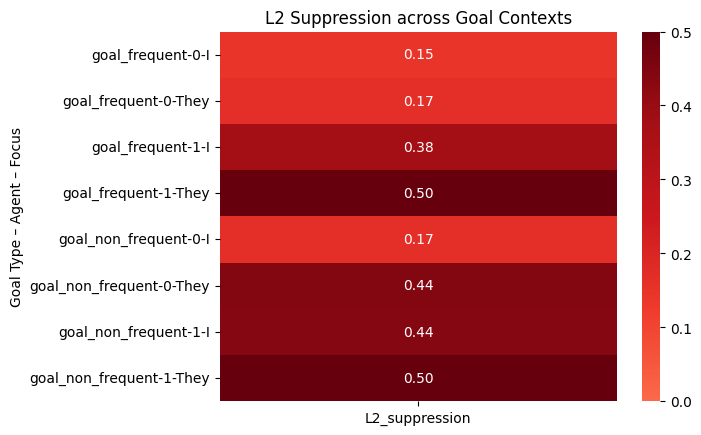

In [69]:
sns.heatmap(
    L2_suppression,
    annot=True,
    cmap="Reds",
    center=0,
    fmt=".2f",
    vmin=0,
    vmax = 0.50
)

plt.title("L2 Suppression across Goal Contexts")
plt.ylabel("Goal Type – Agent – Focus")
plt.xlabel("")
plt.show()

The structure easily appears:

- Regarding Agency:
    - frequent goal:
        - Implicit Agency (0) to Explicit Agency(1):
        Focus = "I": 0.15 --> 0.38; Focus = "They": 0.17 --> 0.50
    - non-frequent goal:
        - Implicit Agency (0) to Explicit Agency(1):
        Focus = "I": 0.17 --> 0.44; Focus = "They": 0.44 --> 0.50

- The Focus difference is visible, particulary under implicit agency in non-frequent goals.

- Goal Type adds something but not as consistent as Agency.


3. From opportunity to modelling

The opportunity analysis identifies a particularly stable descriptive pattern: explicit agency is associated with greater suppression of competing L2 responses across all goal and focus conditions. Focus and Goal Type introduce additional variaton, particularly among implicit agency conditions.

The modelling summary therefore considers 2 complimentary accounts:

- E04: escape_L2 ~ Focus + Agent -a parsimonious account of principal behavioural structure.

- E07: escape_L2 ~ Focus + Agent + Goal type -a broader specification retaining the three theoretical predictors supported by the preceeding analyses.

4. Parsimonious account — E04: escape_L2 ~ Focus + Agent

   → predicted probabilities
   
   → interpretation

Read data

In [70]:
subgroup_theoretical = pd.read_csv("../../data/processed/subgroup_theoretical.csv")

Create escape_L2 binary outcome

In [71]:
subgroup_theoretical["escape_L2"] = (
    subgroup_theoretical["Response_Full"] != "L2_other"
).astype(int)

Get goal context data

In [72]:
goals = subgroup_theoretical[subgroup_theoretical["Goal_Type"]!= "no_goal"].copy()

→ predicted probabilities

In [73]:
# Fit

E04 = smf.logit(
    "escape_L2 ~  Focus + Agent",
    data=goals
    ).fit()

print(E04.summary())

Optimization terminated successfully.
         Current function value: 0.446122
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:              escape_L2   No. Observations:                  132
Model:                          Logit   Df Residuals:                      129
Method:                           MLE   Df Model:                            2
Date:                Sat, 08 Aug 2026   Pseudo R-squ.:                  0.1009
Time:                        18:36:46   Log-Likelihood:                -58.888
converged:                       True   LL-Null:                       -65.495
Covariance Type:            nonrobust   LLR p-value:                  0.001351
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         0.6432      0.298      2.156      0.031       0.058       1.228
Focus[T.They]     0.


- reference Focus = I
- reference Agent = 0
- Focus[T.they] = 0.8763
- Agent = 1.8410

In [74]:
# Prediction grid

E04_pred = pd.DataFrame({
    "Focus": ["I", "I", "They", "They"],
    "Agent": [0, 1, 0, 1]
    })

E04_pred

,Focus,Agent
0,I,0
1,I,1
2,They,0
3,They,1


In [75]:
# Predict

E04_pred["Predicted_probability"] = E04.predict(E04_pred)

E04_pred

,Focus,Agent,Predicted_probability
0,I,0,0.655482
1,I,1,0.923027
2,They,0,0.820468
3,They,1,0.966447


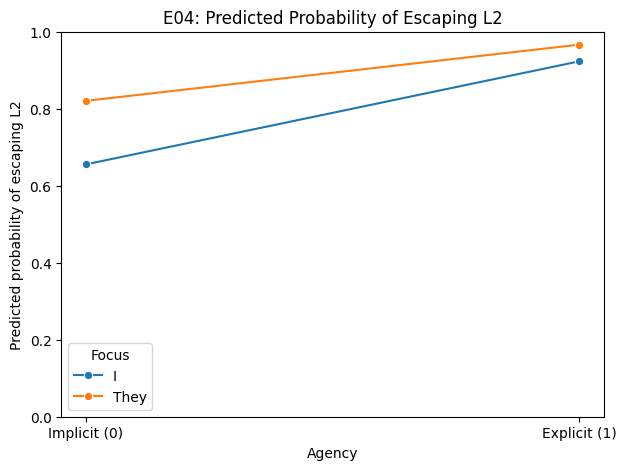

In [76]:
# E04 predicted probabilities plot

plt.figure(figsize=(7, 5))

sns.lineplot(
    data=E04_pred,
    x="Agent",
    y="Predicted_probability",
    hue="Focus",
    marker="o"
)

plt.xticks([0, 1], ["Implicit (0)", "Explicit (1)"])
plt.ylim(0, 1)

plt.xlabel("Agency")
plt.ylabel("Predicted probability of escaping L2")
plt.title("E04: Predicted Probability of Escaping L2")

plt.legend(title="Focus")
plt.show()

 → interpretation:

* Both lines rise: explicit agency increases the predicted probability of escaping L2.
* "They" stays above "I": being an observer also increases escape probability.
* Agency produces the particularly conspicuous movement for "I": roughly 0.66 to 0.92 (vs. 0.82 to 0.96 for "They").
* By explicit agency, both conditions are already very high, so the probability scale naturally compresses the remaining difference.

5. Broader theoretical account — E07: escape_L2 ~ Focus + Agent + Goal_Type

   → predicted probabilities
   
   → interpretation

→ predicted probabilities

In [77]:
# Fit

E07 = smf.logit(
    "escape_L2 ~  Focus + Agent + Goal_Type",
    data=goals
    ).fit()

print(E07.summary())

Optimization terminated successfully.
         Current function value: 0.438864
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:              escape_L2   No. Observations:                  132
Model:                          Logit   Df Residuals:                      128
Method:                           MLE   Df Model:                            3
Date:                Sat, 08 Aug 2026   Pseudo R-squ.:                  0.1155
Time:                        18:36:46   Log-Likelihood:                -57.930
converged:                       True   LL-Null:                       -65.495
Covariance Type:            nonrobust   LLR p-value:                  0.001709
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept                          0.3380      0.368      0.918     

- reference Focus = I
- reference Goal_Type = goal_frequent
- reference Agent = 0
- Focus[T.they] = 0.8919
- Goal_Type[T.goal_non_frequent] = 0.6438
- Agent = 1.8656 

In [78]:
# Prediction grid

E07_pred = pd.DataFrame({
    "Focus": [
        "I", "I", "They", "They",
        "I", "I", "They", "They"
    ],
    "Agent": [
        0, 1, 0, 1,
        0, 1, 0, 1
    ],
    "Goal_Type": [
        "goal_frequent", "goal_frequent",
        "goal_frequent", "goal_frequent",
        "goal_non_frequent", "goal_non_frequent",
        "goal_non_frequent", "goal_non_frequent"
    ]
})

In [79]:
# Predict

E07_pred["Predicted_probability"] = E07.predict(E07_pred)
E07_pred

,Focus,Agent,Goal_Type,Predicted_probability
0,I,0,goal_frequent,0.583703
1,I,1,goal_frequent,0.900573
2,They,0,goal_frequent,0.773794
3,They,1,goal_frequent,0.956706
4,I,0,goal_non_frequent,0.727459
5,I,1,goal_non_frequent,0.945183
6,They,0,goal_non_frequent,0.866878
7,They,1,goal_non_frequent,0.976780


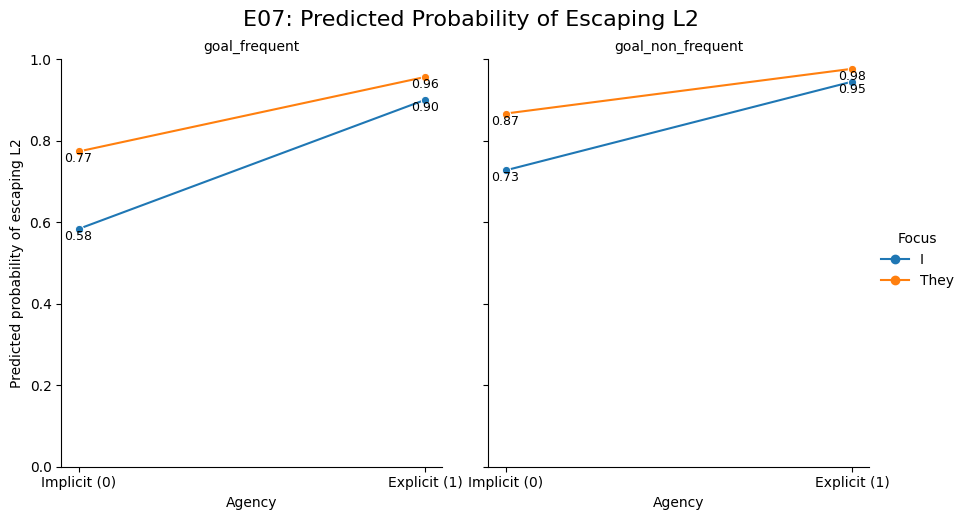

In [80]:
# E07 predicted probabilities plot

g = sns.relplot(
    data=E07_pred,
    x="Agent",
    y="Predicted_probability",
    hue="Focus",
    col="Goal_Type",
    kind="line",
    marker="o",
    height=5,
    aspect=0.9
)

# Fixed probability scale
g.set(
    ylim=(0, 1),
    xticks=[0, 1]
)

# Axis labels
g.set_axis_labels(
    "Agency",
    "Predicted probability of escaping L2"
)

# Panel titles
g.set_titles("{col_name}")

# Replace 0/1 with meaningful labels
for ax in g.axes.flat:
    ax.set_xticklabels(["Implicit (0)", "Explicit (1)"])

g.figure.subplots_adjust(wspace=0.12)

# Overall title
g.figure.suptitle(
    "E07: Predicted Probability of Escaping L2",
    y=1.03,
    fontsize=16
)

for ax, goal_type in zip(g.axes.flat, E07_pred["Goal_Type"].unique()):
    panel_data = E07_pred[
        E07_pred["Goal_Type"] == goal_type
    ]
    for _, row in panel_data.iterrows():
        ax.text(
            row["Agent"],
            row["Predicted_probability"] - 0.027,
            f'{row["Predicted_probability"]:.2f}',
            ha="center",
            fontsize=9
        )

plt.show()


 → interpretation:

* Agency is doing the real lifting. In every combination, going from implicit to explicit agency raises the predicted probability of escaping the L2-other landscape. This is expected given the coefficient and its significance (Agent = 1.8656, p=0.004).
* At both Agency levels and in both goal types, "They" is above "I". It isn't individually conventionally significant (p= 0.078) but it contributes consistently and in the direction of what opportunity analysis showed. 
* Teh non-frequent goal type shifts the whole structure upward. Every non-frequent probability is higher than its frequent goal counterpart's probability. Again, non significant on its own (p=0.171) but coherent with the descriptive L2-suppression pattern shown in opportunity analysis.

6. E04 vs E07

   → What remains stable?

The Agency and Focus structure. Explicit agency consistently increases the predicted probability of escaping L2, while external focus (They) produces higher predicted probabilities than embodied focus (I). E07 preserves the pattern already visible in E04.

   → What does Goal Type add?

It reveals that E04’s probabilities average over a systematic goal-type distinction. Once Goal Type is included, non-frequent goals consistently occupy a higher probability range than their frequent-goal counterparts. Thus, Goal Type does not alter the basic Focus–Agency structure; it locates that structure differently within the probability space.

This is consistent with the descriptive L2-suppression metric, where non-frequent goals generally showed greater suppression than their frequent-goal counterparts, while explicit agency remained the most consistent source of increased suppression


7. Escape_L2 synthesis

Across the opportunity analysis and logistic models, escape from alternative L2 responses appears to be structured primarily by agency, with focus and goal type refining that pattern rather than overturning it.

Explicit agency consistently increases the probability of escaping L2_other responses. This pattern is already visible in the descriptive L2-suppression metric and remains stable in both E04 and E07. Focus adds a second, weaker but systematic distinction: scenarios observed from an external perspective (They) generally produce greater L2 suppression than scenarios embodied by the participant (I).

Goal Type adds further resolution. Non-frequent goals tend to occupy a higher escape-probability range than frequent goals, while preserving the same underlying Focus–Agency structure. In this sense, Goal Type does not redefine the mechanism identified by the simpler model; it locates that structure differently within the probability space.

Taken together, the results suggest that escaping alternative L2 strategies is not best understood as the consequence of one isolated predictor. Instead, explicit agency provides the strongest behavioural push away from competing L2 forms, while perspective and goal characteristics determine the conditions under which that shift becomes more or less pronounced.